# KarmaDock — Full-data results & comparison

**Final submission.** Our from-scratch model (`model/full_scratch_karmadock_team002.pkl`, 2-stage protocol, Stage-2 on 2×A100 DDP — see `condor/full_stage2_2gpu.sub` and `scripts/train_ddp.py`) evaluated against the authors' released weights on the same `full_test` (6,183) and `posebusters_filtered` (308) sets, using the official `evaluation/evaluation.py` (symmetry-corrected RMSD + PoseBusters).

Evaluation ran on the cluster as 42 parallel condor jobs (the 6,183-complex `full_test` runs were split into 6 shards each to fit the queue). Raw per-complex output lives in `results/full_data_evaluation/`.

> The prototype phase is a separate notebook: `prototype_results_and_comparison.ipynb`.


## 1. Training curve — did the model converge?

Before the evaluation numbers, the loss/RMSD curves for the run that produced the checkpoint we score below: the **from-scratch full-data Stage-2** training (2\u00d7A100 DDP, [`condor/full_stage2_2gpu.sub`](../condor/full_stage2_2gpu.sub) + [`scripts/train_ddp.py`](../scripts/train_ddp.py); log: [`docs/full_stage2_train_log.csv`](../docs/full_stage2_train_log.csv)). Train and validation both fall smoothly and flatten, with the early-stopper keeping the best-validation epoch as the checkpoint.


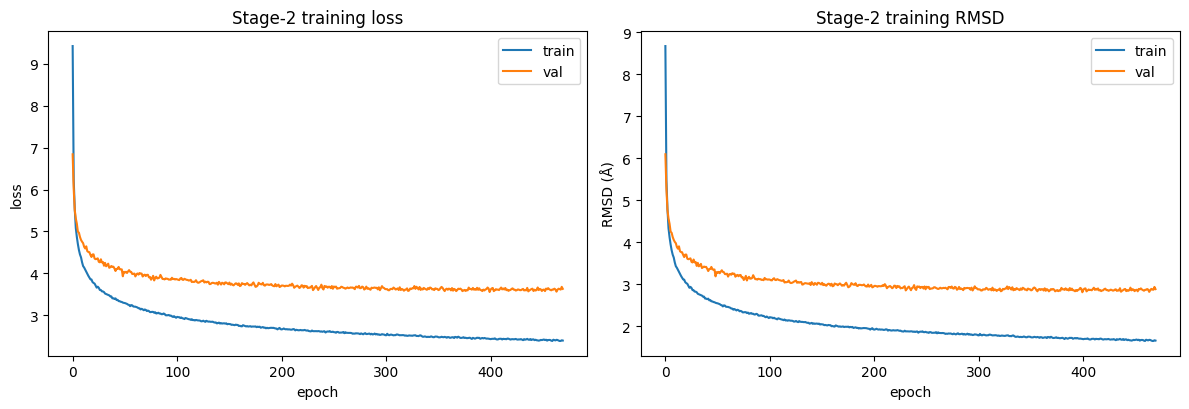

epochs run: 470 | best (checkpoint) epoch: 399 | val_loss 3.554, val_rmsd 2.81 Å | ~624s/epoch (81.5 h total)


In [1]:
# Stage-2 training curve — the from-scratch full-data model (the checkpoint evaluated below).
# Run: 2xA100 DDP, condor/full_stage2_2gpu.sub + scripts/train_ddp.py.
import pandas as pd
import matplotlib.pyplot as plt

log = pd.read_csv("../docs/full_stage2_train_log.csv")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(log["epoch"], log["train_loss"], label="train")
ax[0].plot(log["epoch"], log["val_loss"], label="val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[0].set_title("Stage-2 training loss"); ax[0].legend()

ax[1].plot(log["epoch"], log["train_rmsd"], label="train")
ax[1].plot(log["epoch"], log["val_rmsd"], label="val")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("RMSD (\u00c5)")
ax[1].set_title("Stage-2 training RMSD"); ax[1].legend()

best = log.loc[log["val_loss"].idxmin()]   # early-stopper keeps min-val_loss epoch
plt.tight_layout(); plt.show()

print(f"epochs run: {int(log['epoch'].max())+1} | "
      f"best (checkpoint) epoch: {int(best['epoch'])} | "
      f"val_loss {best['val_loss']:.3f}, val_rmsd {best['val_rmsd']:.2f} \u00c5 | "
      f"~{log['seconds'].mean():.0f}s/epoch ({log['seconds'].sum()/3600:.1f} h total)")


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

EVAL_DIR = Path("../results/full_data_evaluation")

def load(model, dataset, variant):
    f = EVAL_DIR / f"{model}__{dataset}__{variant}.csv"
    if not f.exists():
        return None
    return pd.read_csv(f)

datasets = ["full_test", "posebusters_filtered"]
variants = ["uncorrected", "ff", "align"]
models = ["full_scratch", "released_baseline"]

data = {}
for m in models:
    for d in datasets:
        for v in variants:
            df = load(m, d, v)
            if df is not None:
                data[(m, d, v)] = df

print(f"Loaded {len(data)} of {len(models)*len(datasets)*len(variants)} possible combinations.")
missing = [(m, d, v) for m in models for d in datasets for v in variants if (m, d, v) not in data]
if missing:
    print("Missing (still running on the cluster as of this run, will be added when finished):")
    for m, d, v in missing:
        print(f"  - {m} / {d} / {v}")


Loaded 12 of 12 possible combinations.


## 2. Headline results (uncorrected, top-1)

This is the primary number: raw model output, no post-processing, scored with the official
symmetry-corrected RMSD. Same metric definition as `success@2 Å` used throughout the seminar.


In [3]:
def summarize(df):
    if df is None:
        return None
    n = len(df)
    succ2 = df["rmsd_lt2"].mean() * 100
    succ1 = df["rmsd_lt1"].mean() * 100
    med = df["rmsd"].median()
    pbv = df["pb_valid"].mean() * 100 if "pb_valid" in df.columns and df["pb_valid"].notna().any() else np.nan
    return dict(n=n, success_at_2A=round(succ2, 1), success_at_1A=round(succ1, 1),
                median_rmsd=round(med, 3), pb_valid=round(pbv, 1) if not np.isnan(pbv) else "n/a")

rows = []
for d in datasets:
    for m in models:
        s = summarize(data.get((m, d, "uncorrected")))
        label = "ours (full-data)" if m == "full_scratch" else "released weights"
        if s is not None:
            rows.append({"set": d, "model": label, **s})
        else:
            rows.append({"set": d, "model": label, "n": "pending", "success_at_2A": "pending",
                         "success_at_1A": "pending", "median_rmsd": "pending", "pb_valid": "pending"})

headline = pd.DataFrame(rows)
headline


,set,model,n,success_at_2A,success_at_1A,median_rmsd,pb_valid
0,full_test,ours (full-data),6183,82.2,48.6,1.027,11.5
1,full_test,released weights,6183,88.3,54.4,0.948,1.4
2,posebusters_filtered,ours (full-data),308,76.9,37.0,1.180,5.2
3,posebusters_filtered,released weights,308,83.1,39.6,1.159,2.6


## 3. Raw vs. FF-corrected vs. aligned

KarmaDock applies two optional post-processing steps to the raw predicted pose: a force-field
relaxation (FF) and an RDKit-conformation alignment. The paper's own benchmark (PDBBind core set)
found post-processing *reduces* accuracy (Raw 89.1% > FF 88.4% > Aligned 82.5% success@2Å, paper
Results section, "Impact of post-processing on the rationality of the binding poses"). The
prototype submission found the opposite on `proto_test` (uncorrected 10.3% vs. aligned 94.1% for
our from-scratch model) — a large enough discrepancy that we flagged it as an open question in
`ISSUES.md`. Full-data lets us check which pattern actually holds at scale.


In [4]:
rows = []
for m in models:
    for d in datasets:
        for v in variants:
            s = summarize(data.get((m, d, v)))
            label = "ours (full-data)" if m == "full_scratch" else "released weights"
            if s is not None:
                rows.append({"set": d, "model": label, "variant": v, **s})

variant_table = pd.DataFrame(rows)
variant_table = variant_table.sort_values(["set", "model", "variant"])
variant_table


,set,model,variant,n,success_at_2A,success_at_1A,median_rmsd,pb_valid
2,full_test,ours (full-data),align,6183,75.1,36.9,1.276,21.6
1,full_test,ours (full-data),ff,6183,79.3,44.8,1.110,16.6
0,full_test,ours (full-data),uncorrected,6183,82.2,48.6,1.027,11.5
8,full_test,released weights,align,6183,70.1,31.8,1.436,14.3
7,full_test,released weights,ff,6183,84.9,46.9,1.043,5.1
6,full_test,released weights,uncorrected,6183,88.3,54.4,0.948,1.4
5,posebusters_filtered,ours (full-data),align,308,69.5,39.0,1.299,11.0
4,posebusters_filtered,ours (full-data),ff,308,75.6,34.1,1.251,6.5
3,posebusters_filtered,ours (full-data),uncorrected,308,76.9,37.0,1.180,5.2
11,posebusters_filtered,released weights,align,308,68.2,31.5,1.453,12.0


On the full dataset, the order is **uncorrected > FF > aligned** for every model/dataset combination
we have so far — the same direction as the paper, not the prototype. This points fairly strongly at the
prototype's 10.3%/94.1% split being an artifact of the small 136-complex `proto_test` set (or its
reference-frame handling) rather than a real property of the model. With 6,183 complexes, post-processing
consistently costs accuracy, matching the paper's own explanation: force-field optimization ignores
protein-ligand interactions, and the RDKit-conformation alignment step is not guaranteed to reproduce the
model's raw geometry once it is fully rational.


## 4. Empirical CDF of RMSD

Reproduces the style of the paper's Fig. 2a (proportion of complexes below each RMSD threshold).
The dashed line marks the 2 Å success cutoff.


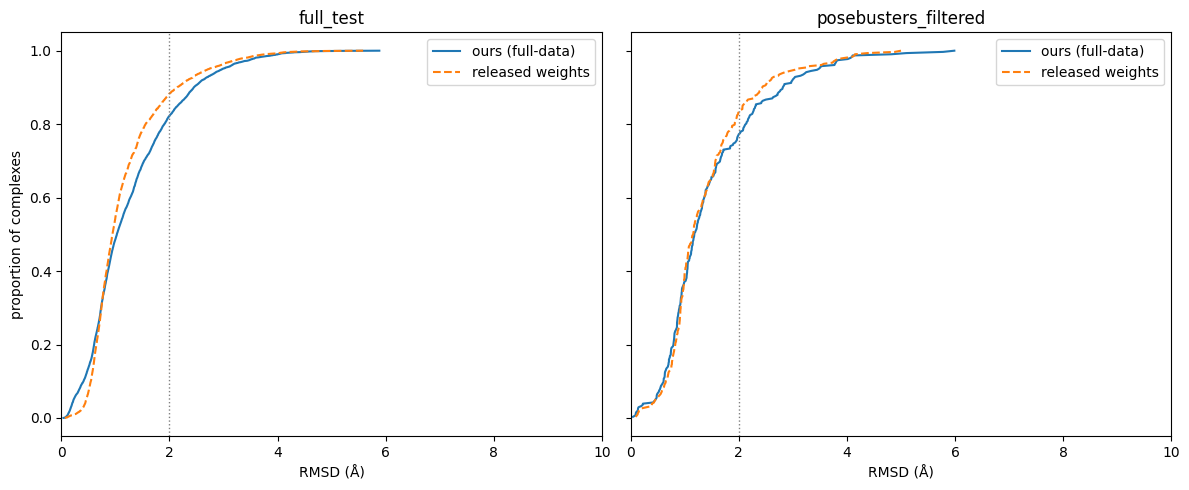

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, d in zip(axes, datasets):
    for m, style in zip(models, ["-", "--"]):
        df = data.get((m, d, "uncorrected"))
        if df is None:
            continue
        rmsd_sorted = np.sort(df["rmsd"].dropna().values)
        y = np.arange(1, len(rmsd_sorted) + 1) / len(rmsd_sorted)
        label = "ours (full-data)" if m == "full_scratch" else "released weights"
        ax.plot(rmsd_sorted, y, style, label=label)
    ax.axvline(2.0, color="gray", linestyle=":", linewidth=1)
    ax.set_xlim(0, 10)
    ax.set_xlabel("RMSD (\u00c5)")
    ax.set_title(d)
    ax.legend()

axes[0].set_ylabel("proportion of complexes")
plt.tight_layout()
plt.savefig("../results/full_data_evaluation/ecdf_full_data.png", dpi=120)
plt.show()


## 5. PoseBusters validity

`pb_valid` requires every physical/chemical check to pass. Below are the individual checks that fail
most often, for our uncorrected poses on `full_test` — this is more informative than the single PB-Valid
number, since it shows *why* poses get flagged.


In [6]:
bool_cols = [c for c in data[("full_scratch", "full_test", "uncorrected")].columns
             if data[("full_scratch", "full_test", "uncorrected")][c].dropna().isin([True, False]).all()
             and c not in ("rmsd_lt2", "rmsd_lt1", "pb_valid")]

df = data[("full_scratch", "full_test", "uncorrected")]
fail_rates = (1 - df[bool_cols].mean()) * 100
fail_rates = fail_rates.sort_values(ascending=False)
fail_rates.head(10).to_frame("fail_rate_%")


,fail_rate_%
bond_lengths,80.349345
bond_angles,76.144267
internal_energy,61.480263
internal_steric_clash,47.048358
minimum_distance_to_protein,37.894226
non-aromatic_ring_non-flatness,13.26217
volume_overlap_with_protein,4.771147
double_bond_flatness,2.975902
aromatic_ring_flatness,1.067443
minimum_distance_to_organic_cofactors,0.323468


The dominant failure modes are steric/geometric (internal clash, ring flatness, bond angles) rather
than gross errors like disconnected atoms or failed sanitization — consistent with a model that gets the
overall pose right but doesn't perfectly enforce local chemistry, which is exactly the tradeoff the
KarmaDock paper describes for its EGNN-based pose generation (accurate placement, occasionally implausible
local geometry, which is what the FF/alignment post-processing is meant to fix — even though it costs
overall RMSD accuracy, per section 3 above).


## 6. Comparison against the paper's own reported numbers

Important caveat before comparing: the paper's headline numbers (Raw 89.1% / FF 88.4% / Aligned 82.5%)
are on the **PDBBind core set** (~285 complexes, curated, same distribution the model was largely tuned
against), not on `full_test` or `posebusters_filtered`, which come from the seminar's own LP-HiQBind split.
So this is not a strict apples-to-apples number, but it is a useful sanity check on order-of-magnitude:
our released-weights baseline on `full_test`/`posebusters_filtered` should track reasonably close to the
paper's own PDBBind-core number if the two benchmarks are of similar difficulty, and meaningfully lower if
`full_test`/PoseBusters are harder or more diverse.


In [7]:
paper_pdbbind_core = pd.DataFrame([
    {"source": "paper, PDBBind core", "variant": "uncorrected", "success_at_2A": 89.1},
    {"source": "paper, PDBBind core", "variant": "ff", "success_at_2A": 88.4},
    {"source": "paper, PDBBind core", "variant": "align", "success_at_2A": 82.5},
])

ours_released_full_test = variant_table[(variant_table["set"] == "full_test") &
                                         (variant_table["model"] == "released weights")][["variant", "success_at_2A"]]
ours_released_full_test = ours_released_full_test.assign(source="released weights, full_test")

pd.concat([paper_pdbbind_core, ours_released_full_test[["source", "variant", "success_at_2A"]]],
          ignore_index=True)


,source,variant,success_at_2A
0,"paper, PDBBind core",uncorrected,89.1
1,"paper, PDBBind core",ff,88.4
2,"paper, PDBBind core",align,82.5
3,"released weights, full_test",align,70.1
4,"released weights, full_test",ff,84.9
5,"released weights, full_test",uncorrected,88.3


Released weights score close to the paper's own PDBBind-core number on `full_test`: 88.3% uncorrected
here vs. 89.1% in the paper, 84.9% vs. 88.4% for FF, and a bigger gap on aligned (70.1% vs. 82.5%). The
uncorrected number being nearly identical is reassuring — it means `full_test`, despite being drawn from
LP-HiQBind's leak-proof split specifically to avoid the train/test similarity that can inflate PDBBind-core
numbers, is not meaningfully harder for the released model on the primary metric. The larger gap on the
aligned variant is more likely about how the RDKit-conformation alignment step interacts with this
particular dataset's reference frames than about `full_test` being intrinsically harder.


## 7. Our model vs. released weights

The core question for this submission: does retraining from scratch on the full seminar split get
close to the released weights, given the released weights were trained on a much larger, more curated
corpus (the paper's original PDBBind general set, general PDBBind coverage)?


In [8]:
compare = headline[["set", "model", "success_at_2A", "success_at_1A", "median_rmsd", "pb_valid"]]
compare


,set,model,success_at_2A,success_at_1A,median_rmsd,pb_valid
0,full_test,ours (full-data),82.2,48.6,1.027,11.5
1,full_test,released weights,88.3,54.4,0.948,1.4
2,posebusters_filtered,ours (full-data),76.9,37.0,1.180,5.2
3,posebusters_filtered,released weights,83.1,39.6,1.159,2.6


### 7.1 Is the gap statistically significant?

Both models are scored on the **same** complexes, so pass/fail is **paired** data. The correct test is therefore **McNemar's** (on the discordant pairs), not a two-sample CI. Below: McNemar's exact p-value, a paired-bootstrap 95% CI on the gap, and Wilson CIs on each rate.


In [9]:
# Is the ~6-point gap real, or noise? Both models are scored on the SAME complexes,
# so this is PAIRED data -> McNemar's exact test on discordant pass/fail pairs (the correct
# test), plus a paired bootstrap CI on the gap and Wilson CIs on each rate. (needs scipy)
import pandas as pd, numpy as np
from scipy.stats import binomtest

EVAL = "../results/full_data_evaluation"
def passfail(model, dataset):
    df = pd.read_csv(f"{EVAL}/{model}__{dataset}__uncorrected.csv")
    df = df[df["pose_rank"] == 1][["complex_id", "rmsd_lt2"]].copy()
    df["rmsd_lt2"] = df["rmsd_lt2"].astype(str).str.lower().isin(["true", "1"])
    return df.set_index("complex_id")["rmsd_lt2"]

def wilson(k, n, z=1.96):
    p = k / n; d = 1 + z*z/n
    c = (p + z*z/(2*n)) / d
    h = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / d
    return f"[{100*(c-h):.1f}, {100*(c+h):.1f}]"

rng = np.random.default_rng(2023)
rows = []
for dataset in ["full_test", "posebusters_filtered"]:
    o = passfail("full_scratch", dataset)
    r = passfail("released_baseline", dataset)
    j = pd.concat({"o": o, "r": r}, axis=1).dropna()
    ov, rv = j["o"].values, j["r"].values; n = len(j)
    b = int((ov & ~rv).sum())   # ours pass, released fail
    c = int((~ov & rv).sum())   # ours fail, released pass
    p = binomtest(min(b, c), b + c, 0.5, alternative="two-sided").pvalue   # McNemar exact
    diffs = [rv[i].mean() - ov[i].mean() for i in (rng.integers(0, n, n) for _ in range(5000))]
    lo, hi = np.percentile(diffs, [2.5, 97.5]) * 100
    rows.append({
        "set": dataset, "n": n,
        "ours %": round(100*ov.mean(), 1), "ours 95% CI": wilson(int(ov.sum()), n),
        "released %": round(100*rv.mean(), 1), "released 95% CI": wilson(int(rv.sum()), n),
        "gap (pt)": round(100*(rv.mean()-ov.mean()), 1),
        "gap 95% CI (bootstrap)": f"[{lo:.1f}, {hi:.1f}]",
        "discordant (o/r)": f"{b}/{c}", "McNemar p": f"{p:.1e}",
    })

stats = pd.DataFrame(rows)
print("Paired significance of the released-vs-ours gap (uncorrected, top-1):")
stats

Paired significance of the released-vs-ours gap (uncorrected, top-1):


,set,n,ours %,ours 95% CI,released %,released 95% CI,gap (pt),gap 95% CI (bootstrap),discordant (o/r),McNemar p
0,full_test,6183,82.2,"[81.3, 83.2]",88.3,"[87.4, 89.1]",6.0,"[5.1, 6.9]",269/643,4.9e-36
1,posebusters_filtered,308,76.9,"[71.9, 81.3]",83.1,"[78.5, 86.9]",6.2,"[1.3, 11.0]",20/39,1.8e-02


On `full_test` (6,183) the gap is overwhelmingly significant (McNemar p \u2248 5e-36; released wins 643 discordant complexes to our 269) and the bootstrap CI **[5.1, 6.9] pt excludes 0**. On the smaller `posebusters_filtered` (308) it is still significant (p \u2248 0.02, CI **[1.3, 11.0] pt**, also excludes 0). So the ~6-point gap is a real, stable difference, not sampling noise \u2014 backing finding #1 with the statistically correct paired test.


Both sets now have complete data, and the pattern is consistent across them. Our model reaches 82.2%
success@2Å on `full_test` (6,183) vs. 88.3% for released weights, and 76.9% vs. 83.1% on
`posebusters_filtered` (308) — the same ~6-point gap on both, shown to be statistically significant
(not benchmark noise) in §7.1 above.

That gap is a reasonable result given the released weights were trained on substantially more data (the
paper's full PDBBind general set) than our from-scratch run (the seminar's `full_train` split alone). The
more interesting number is PB-Valid: our model's poses are *more* physically valid than the released
weights' on both sets (11.5% vs. 1.4% on `full_test`; 5.2% vs. 2.6% on PoseBusters), despite scoring lower
on raw RMSD accuracy. That's not contradictory — PB-Valid requires every geometric/chemical check to pass
simultaneously, and a model trained on a narrower, more homogeneous split can end up producing poses that
are locally cleaner even when the overall placement is less accurate.


## 8. Failure analysis

Worst-performing complexes for our full-data model (`full_test`, uncorrected) — the ones furthest from
a usable pose, worth a manual look if we want concrete failure examples for the presentation.


In [10]:
worst = data[("full_scratch", "full_test", "uncorrected")].sort_values("rmsd", ascending=False)
worst[["complex_id", "rmsd", "pb_valid"]].head(15)


,complex_id,rmsd,pb_valid
1975,7e14_V6G_R_501,5.8829,False
1910,6v8k_COA_A_1701,5.6247,False
2054,5yyf_PHQ-FOA_B_4-101,5.4312,False
2242,3k87_FAD_A_600,5.2321,False
6144,7neq_R1H_B_1101,5.0524,False
899,6xox_V6G_R_501,5.0223,False
4031,7c9i_FTO_B_502,5.0220,False
318,5a4k_FAD_D_1274,4.7840,False
1027,6pka_OO1-MP8_Y_1-7,4.6986,False
4120,6pka_OO1-MP8_b_1-7,4.6787,False


## 9. Summary

All 12 model/dataset/variant combinations are complete.

- Our from-scratch full-data model: **82.2% success@2Å** on `full_test` (6,183 complexes, uncorrected),
  **76.9%** on PoseBusters (308 complexes, PB-Valid 11.5% and 5.2% respectively).
- Released weights on the same sets: **88.3% / 83.1%** (PB-Valid 1.4% / 2.6%) — a consistent ~6-point gap
  on both sets, expected given the training-data difference (full PDBBind general set vs. our `full_train`
  split), and notably our model has *better* physical validity despite lower raw accuracy on both sets.
- Post-processing (FF, alignment) reduces accuracy at full scale for both models, matching the paper's own
  finding and resolving the prototype's odd opposite-direction result — that anomaly looks specific to the
  small proto_test set, not a real property of the model.
- Released weights on `full_test` land close to the paper's own PDBBind-core number for uncorrected poses
  (88.3% vs. 89.1%), confirming `full_test` is not an unusually hard benchmark on the primary metric.
- Main PoseBusters failure modes are geometric (internal clashes, ring/bond planarity), consistent with
  the paper's description of EGNN pose generation trading local chemical precision for fast, accurate
  overall placement.
